<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

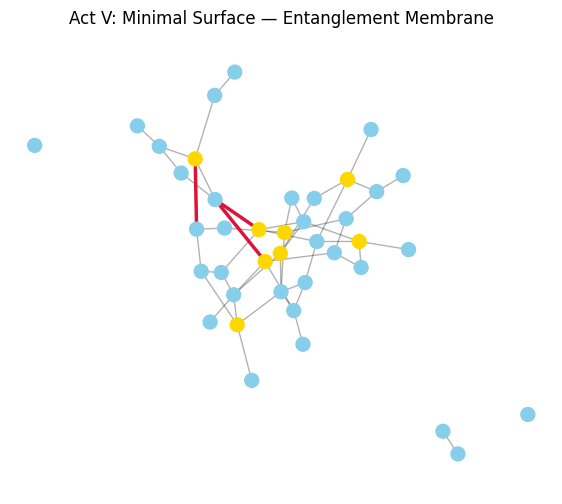

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Build Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.05:
                G.add_edge(f"U{i}", f"U{j}")

    return G, boundary_nodes, bulk_nodes

# -------------------------------
# Step 2: Assign δ and κ at Equilibrium
# -------------------------------
def assign_equilibrium_weights(G, δ=0.8, κ=0.8):
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = δ if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = κ if region == 'bulk' else 0.0

# -------------------------------
# Step 3: Define Edge Weights
# -------------------------------
def assign_edge_weights(G):
    for u, v in G.edges:
        δ_u = G.nodes[u]['delta']
        κ_u = G.nodes[u]['kappa']
        δ_v = G.nodes[v]['delta']
        κ_v = G.nodes[v]['kappa']
        entanglement_strength = δ_u * κ_v + δ_v * κ_u
        G.edges[u, v]['weight'] = 1.0 - entanglement_strength  # inverse for minimal cut

# -------------------------------
# Step 4: Extract Minimal Surface
# -------------------------------
def extract_minimal_surface(G, boundary_nodes, bulk_nodes):
    cut_value, partition = nx.minimum_cut(G, boundary_nodes[0], bulk_nodes[0], capacity='weight')
    reachable, non_reachable = partition
    cut_edges = [(u, v) for u, v in G.edges if (u in reachable and v in non_reachable) or (v in reachable and u in non_reachable)]
    return cut_edges

# -------------------------------
# Step 5: Visualize Surface
# -------------------------------
def plot_minimal_surface(G, cut_edges):
    pos = nx.spring_layout(G, seed=42)
    fig, ax = plt.subplots(figsize=(7, 6))
    nx.draw_networkx_nodes(G, pos, node_size=100, ax=ax,
                           node_color=['gold' if G.nodes[n]['region'] == 'boundary' else 'skyblue' for n in G.nodes])
    nx.draw_networkx_edges(G, pos, edgelist=G.edges, alpha=0.3, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='crimson', width=2.5, ax=ax)
    ax.set_title("Act V: Minimal Surface — Entanglement Membrane")
    plt.axis('off')
    plt.show()

# -------------------------------
# Step 6: Run the Ritual
# -------------------------------
G, boundary_nodes, bulk_nodes = build_boundary_bulk_network()
assign_equilibrium_weights(G)
assign_edge_weights(G)
cut_edges = extract_minimal_surface(G, boundary_nodes, bulk_nodes)
plot_minimal_surface(G, cut_edges)
